<h1>
Исследовательская работа - построение модели предсказания совершения покупки в целевом периоде
</h1>

<h2>Цели работы</h2>
<ul>
    <li>
        Анализ основных параметров данных
    </li>
    <li>
        Построение пайплайна модели и нахождение оптимальной модели и её гиперпараметров
    </li>
	<li>
		Расчёт показателей на тестовой выборке
    </li>
</ul>
<h2>План</h2>
<ul>
    <li>
        Загрузка данных
    </li>
    <li>
        Генерация новых синтетических признаков
    </li>
	<li>
        Корреляционный анализ
    </li>
	<li>
		Построение пайплайна модели и поиск гиперпараметров
    </li>
	<li>
		Расчёт тестовых показателей
    </li>
	<li>
		Вывод
    </li>
</ul>

### Загрузка данных

In [1]:
import pandas as pd
from IPython.display import display
import matplotlib.pyplot as plt

import numpy as np

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder, StandardScaler, MinMaxScaler, RobustScaler
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import roc_auc_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import GradientBoostingClassifier

from phik import phik_matrix

import seaborn as sns

In [2]:
apparel_messages = pd.read_csv('../data/workShop2/apparel-messages.csv')
apparel_purchases = pd.read_csv('../data/workShop2/apparel-purchases.csv')
apparel_target_binary = pd.read_csv('../data/workShop2/apparel-target_binary.csv')
full_campaign_daily_event_channel = pd.read_csv('../data/workShop2/full_campaign_daily_event_channel.csv')
full_campaign_daily_event = pd.read_csv('../data/workShop2/full_campaign_daily_event.csv')

In [3]:
display(full_campaign_daily_event.head(15))
full_campaign_daily_event.info()
print(full_campaign_daily_event.columns)

,date,bulk_campaign_id,count_click,count_complain,count_hard_bounce,count_open,count_purchase,count_send,count_soft_bounce,count_subscribe,...,nunique_open,nunique_purchase,nunique_send,nunique_soft_bounce,nunique_subscribe,nunique_unsubscribe,count_hbq_spam,nunique_hbq_spam,count_close,nunique_close
0,2022-05-19,563,0,0,0,4,0,0,0,0,...,4,0,0,0,0,0,0,0,0,0
1,2022-05-19,577,0,0,0,1,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
2,2022-05-19,622,0,0,0,2,0,0,0,0,...,2,0,0,0,0,0,0,0,0,0
3,2022-05-19,634,0,0,0,1,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
4,2022-05-19,676,0,0,0,1,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
5,2022-05-19,764,0,0,0,2,0,0,0,0,...,2,0,0,0,0,0,0,0,0,0
6,2022-05-19,766,0,0,0,2,0,0,0,0,...,2,0,0,0,0,0,0,0,0,0
7,2022-05-19,783,1,0,0,8,0,0,0,0,...,6,0,0,0,0,0,0,0,0,0
8,2022-05-19,817,0,0,0,2,0,0,0,0,...,2,0,0,0,0,0,0,0,0,0
9,2022-05-19,833,0,0,0,1,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 131072 entries, 0 to 131071
Data columns (total 24 columns):
 #   Column               Non-Null Count   Dtype 
---  ------               --------------   ----- 
 0   date                 131072 non-null  object
 1   bulk_campaign_id     131072 non-null  int64 
 2   count_click          131072 non-null  int64 
 3   count_complain       131072 non-null  int64 
 4   count_hard_bounce    131072 non-null  int64 
 5   count_open           131072 non-null  int64 
 6   count_purchase       131072 non-null  int64 
 7   count_send           131072 non-null  int64 
 8   count_soft_bounce    131072 non-null  int64 
 9   count_subscribe      131072 non-null  int64 
 10  count_unsubscribe    131072 non-null  int64 
 11  nunique_click        131072 non-null  int64 
 12  nunique_complain     131072 non-null  int64 
 13  nunique_hard_bounce  131072 non-null  int64 
 14  nunique_open         131072 non-null  int64 
 15  nunique_purchase     131072 non-nu

In [4]:
display(apparel_messages.head(15))
apparel_messages.info()
print(apparel_messages['event'].unique())

,bulk_campaign_id,client_id,message_id,event,channel,date,created_at
0,4439,1515915625626736623,1515915625626736623-4439-6283415ac07ea,open,email,2022-05-19,2022-05-19 00:14:20
1,4439,1515915625490086521,1515915625490086521-4439-62834150016dd,open,email,2022-05-19,2022-05-19 00:39:34
2,4439,1515915625553578558,1515915625553578558-4439-6283415b36b4f,open,email,2022-05-19,2022-05-19 00:51:49
3,4439,1515915625553578558,1515915625553578558-4439-6283415b36b4f,click,email,2022-05-19,2022-05-19 00:52:20
4,4439,1515915625471518311,1515915625471518311-4439-628341570c133,open,email,2022-05-19,2022-05-19 00:56:52
5,4439,1515915625594606468,1515915625594606468-4439-6283411f277fc,open,email,2022-05-19,2022-05-19 01:04:11
6,4439,1515915625491810918,1515915625491810918-4439-6283411d9d299,open,email,2022-05-19,2022-05-19 01:19:54
7,4439,1515915625474219766,1515915625474219766-4439-628341212233a,open,email,2022-05-19,2022-05-19 01:23:43
8,4439,1515915625474219766,1515915625474219766-4439-628341212233a,click,email,2022-05-19,2022-05-19 01:24:16
9,4439,1515915625566741491,1515915625566741491-4439-6283412871599,open,email,2022-05-19,2022-05-19 01:31:06


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12739798 entries, 0 to 12739797
Data columns (total 7 columns):
 #   Column            Dtype 
---  ------            ----- 
 0   bulk_campaign_id  int64 
 1   client_id         int64 
 2   message_id        object
 3   event             object
 4   channel           object
 5   date              object
 6   created_at        object
dtypes: int64(2), object(5)
memory usage: 680.4+ MB
['open' 'click' 'purchase' 'send' 'unsubscribe' 'hbq_spam' 'hard_bounce'
 'subscribe' 'soft_bounce' 'complain' 'close']


In [5]:
display(apparel_purchases.head(10))

,client_id,quantity,price,category_ids,date,message_id
0,1515915625468169594,1,1999.0,"['4', '28', '57', '431']",2022-05-16,1515915625468169594-4301-627b661e9736d
1,1515915625468169594,1,2499.0,"['4', '28', '57', '431']",2022-05-16,1515915625468169594-4301-627b661e9736d
2,1515915625471138230,1,6499.0,"['4', '28', '57', '431']",2022-05-16,1515915625471138230-4437-6282242f27843
3,1515915625471138230,1,4999.0,"['4', '28', '244', '432']",2022-05-16,1515915625471138230-4437-6282242f27843
4,1515915625471138230,1,4999.0,"['4', '28', '49', '413']",2022-05-16,1515915625471138230-4437-6282242f27843
5,1515915625471640575,1,3499.0,"['2', '18', '258', '441']",2022-05-16,1515915625471640575-4301-627b661b67ac3
6,1515915625490211585,1,1699.0,"['2', '18', '341', '1311']",2022-05-16,1515915625490211585-4301-627b661843283
7,1515915625490739153,1,1999.0,"['2', '18', '123', '451']",2022-05-16,1515915625490739153-4172-626b943cc789b
8,1515915625491478747,1,999.0,"['5562', '5631', '5549', '667']",2022-05-16,1515915625491478747-4273-6274ceb769d59
9,1515915625491651493,1,699.0,"['5562', '5630', '5649', '678']",2022-05-16,1515915625491651493-4437-6282242f2a9e2


In [6]:
print(apparel_purchases['date'].unique())

['2022-05-16' '2022-05-17' '2022-05-18' '2022-05-19' '2022-05-20'
 '2022-05-21' '2022-05-22' '2022-05-23' '2022-05-24' '2022-05-25'
 '2022-05-26' '2022-05-27' '2022-05-28' '2022-05-29' '2022-05-30'
 '2022-05-31' '2022-06-01' '2022-06-02' '2022-06-03' '2022-06-04'
 '2022-06-05' '2022-06-06' '2022-06-07' '2022-06-08' '2022-06-09'
 '2022-06-10' '2022-06-11' '2022-06-12' '2022-06-13' '2022-06-14'
 '2022-06-15' '2022-06-16' '2022-06-17' '2022-06-18' '2022-06-19'
 '2022-06-20' '2022-06-21' '2022-06-22' '2022-06-23' '2022-06-24'
 '2022-06-25' '2022-06-26' '2022-06-27' '2022-06-28' '2022-06-29'
 '2022-06-30' '2022-07-01' '2022-07-02' '2022-07-03' '2022-07-04'
 '2022-07-05' '2022-07-06' '2022-07-07' '2022-07-08' '2022-07-09'
 '2022-07-10' '2022-07-11' '2022-07-12' '2022-07-13' '2022-07-14'
 '2022-07-15' '2022-07-16' '2022-07-17' '2022-07-18' '2022-07-19'
 '2022-07-20' '2022-07-21' '2022-07-22' '2022-07-23' '2022-07-24'
 '2022-07-25' '2022-07-26' '2022-07-27' '2022-07-28' '2022-07-29'
 '2022-07-

<p>
Загружаем данные и смотрим на их основные параметры.
</p>

### Создание новых признаков

In [7]:
table_for_event_counting = apparel_messages[['client_id', 'event', 'date']]

In [8]:
display(table_for_event_counting)
table_for_event_counting['year'] = table_for_event_counting['date'].apply(lambda x: x.split('-')[0])
display(table_for_event_counting['year'])

,client_id,event,date
0,1515915625626736623,open,2022-05-19
1,1515915625490086521,open,2022-05-19
2,1515915625553578558,open,2022-05-19
3,1515915625553578558,click,2022-05-19
4,1515915625471518311,open,2022-05-19
...,...,...,...
12739793,1515915625477497874,open,2024-02-15
12739794,1515915625765994334,open,2024-02-15
12739795,1515915625545014677,open,2024-02-15
12739796,1515915625477497874,open,2024-02-15


/var/folders/2l/j55kj6cd07q3_76qd6w9vf5h_f4mp_/T/ipykernel_20840/1313464793.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  table_for_event_counting['year'] = table_for_event_counting['date'].apply(lambda x: x.split('-')[0])


0           2022
1           2022
2           2022
3           2022
4           2022
            ... 
12739793    2024
12739794    2024
12739795    2024
12739796    2024
12739797    2024
Name: year, Length: 12739798, dtype: object

In [9]:
events_value_counts = table_for_event_counting
client_ids = events_value_counts['client_id'].unique()
events_value_counts_23 = table_for_event_counting.query('year == "2023"')
client_ids_23 = events_value_counts_23['client_id'].unique()
events_value_counts_24 = table_for_event_counting.query('year == "2024"')
client_ids_24 = events_value_counts_24['client_id'].unique()
events_value_counts = events_value_counts.drop(['year', 'date'], axis = 1)
events_value_counts_23 = events_value_counts_23.drop(['year', 'date'], axis = 1)
events_value_counts_24 = events_value_counts_24.drop(['year', 'date'], axis = 1)
events_value_counts = events_value_counts.value_counts()
events_value_counts_23 = events_value_counts_23.value_counts()
events_value_counts_24 = events_value_counts_24.value_counts()
events = table_for_event_counting['event'].unique()

In [10]:
display(events_value_counts_24)
display(events_value_counts_23)

client_id            event      
1515915625489071904  send           207
1515915625804998560  send           206
1515915625516327994  send           205
1515915625625548006  send           205
1515915625806965679  send           204
                                   ... 
1515915625542406904  open             1
1515915625542393876  hard_bounce      1
1515915625830787674  hard_bounce      1
1515915625542309913  open             1
1515915626010288690  send             1
Name: count, Length: 87797, dtype: int64

client_id            event      
1515915625625548006  send           1533
1515915625516327994  send           1523
1515915625489071904  send           1290
1515915625804998560  send           1070
                     open           1066
                                    ... 
1515915625781028568  open              1
1515915625623457951  click             1
1515915625490405620  click             1
                     hard_bounce       1
1515915625580076884  purchase          1
Name: count, Length: 150118, dtype: int64

In [11]:
messages_types_data = pd.DataFrame(columns=events, index=client_ids)
messages_types_data_23 = pd.DataFrame(columns=events, index=client_ids_23)
messages_types_data_24 = pd.DataFrame(columns=events, index=client_ids_24)

In [12]:
for client_id in client_ids:
	for event in events_value_counts[client_id].index:
		messages_types_data.loc[client_id, event] = events_value_counts[client_id, event]
for client_id in client_ids_23:
	for event in events_value_counts_23[client_id].index:
		messages_types_data_23.loc[client_id, event] = events_value_counts_23[client_id, event]
for client_id in client_ids_24:		
	for event in events_value_counts_24[client_id].index:
		messages_types_data_24.loc[client_id, event] = events_value_counts_24[client_id, event]

In [13]:
messages_types_data = messages_types_data.fillna(0)
messages_types_data_23 = messages_types_data_23.fillna(0)
messages_types_data_24 = messages_types_data_24.fillna(0)
messages_types_data_23 = messages_types_data_23.rename(columns={
	'open': 'open_23',
	'click': 'click_23',
	'purchase': 'purchase_23',
	'send': 'send_23',
	'unsubscribe': 'unsubscribe_23',
	'hbq_spam': 'hbq_spam_23',
	'hard_bounce': 'hard_bounce_23',
	'subscribe': 'subscribe_23',
	'soft_bounce': 'soft_bounce_23',
	'complain': 'complain_23',
	'close': 'close_23'
})
messages_types_data_24 = messages_types_data_24.rename(columns={
	'open': 'open_24',
	'click': 'click_24',
	'purchase': 'purchase_24',
	'send': 'send_24',
	'unsubscribe': 'unsubscribe_24',
	'hbq_spam': 'hbq_spam_24',
	'hard_bounce': 'hard_bounce_24',
	'subscribe': 'subscribe_24',
	'soft_bounce': 'soft_bounce_24',
	'complain': 'complain_24',
	'close': 'close_24'
})
display(messages_types_data.head())
display(messages_types_data_23.head())
display(messages_types_data_24.head())

/var/folders/2l/j55kj6cd07q3_76qd6w9vf5h_f4mp_/T/ipykernel_20840/372603242.py:1: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  messages_types_data = messages_types_data.fillna(0)
/var/folders/2l/j55kj6cd07q3_76qd6w9vf5h_f4mp_/T/ipykernel_20840/372603242.py:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  messages_types_data_23 = messages_types_data_23.fillna(0)
/var/folders/2l/j55kj6cd07q3_76qd6w9vf5h_f4mp_/T/ipykernel_20840/372603242.py:3: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future

,open,click,purchase,send,unsubscribe,hbq_spam,hard_bounce,subscribe,soft_bounce,complain,close
1515915625626736623,79,15,1,384,0,0,0,0,0,0,0
1515915625490086521,427,41,2,447,0,0,0,0,0,0,0
1515915625553578558,158,28,2,262,0,0,1,0,0,0,0
1515915625471518311,71,19,1,167,0,0,1,0,0,0,0
1515915625594606468,158,38,2,193,0,0,0,0,0,0,0


,open_23,click_23,purchase_23,send_23,unsubscribe_23,hbq_spam_23,hard_bounce_23,subscribe_23,soft_bounce_23,complain_23,close_23
1515915625766180244,18,0,0,82,0,0,0,0,0,0,0
1515915625513990782,19,1,0,181,0,0,0,0,0,0,0
1515915625509206917,51,3,0,52,0,0,0,0,0,0,0
1515915625468106976,164,99,3,224,0,0,0,0,0,0,0
1515915625594609629,5,2,2,90,0,0,0,0,0,0,0


,open_24,click_24,purchase_24,send_24,unsubscribe_24,hbq_spam_24,hard_bounce_24,subscribe_24,soft_bounce_24,complain_24,close_24
1515915625621086592,31,2,0,33,0,0,0,0,0,0,0
1515915625919594778,0,3,1,25,0,0,0,0,0,0,0
1515915625953279425,0,0,0,33,0,0,0,0,0,0,0
1515915625502480713,33,0,0,37,0,0,0,0,0,0,0
1515915625539895417,46,2,0,57,0,0,0,0,0,0,0


In [14]:
messages_types_data_24.info()

<class 'pandas.core.frame.DataFrame'>
Index: 43590 entries, 1515915625621086592 to 1515915625549777338
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   open_24         43590 non-null  int64
 1   click_24        43590 non-null  int64
 2   purchase_24     43590 non-null  int64
 3   send_24         43590 non-null  int64
 4   unsubscribe_24  43590 non-null  int64
 5   hbq_spam_24     43590 non-null  int64
 6   hard_bounce_24  43590 non-null  int64
 7   subscribe_24    43590 non-null  int64
 8   soft_bounce_24  43590 non-null  int64
 9   complain_24     43590 non-null  int64
 10  close_24        43590 non-null  int64
dtypes: int64(11)
memory usage: 5.0 MB


In [15]:
display(full_campaign_daily_event.columns)
display(full_campaign_daily_event)
columns_to_drop = [
	'date',
	'count_send',
	'nunique_click',
	'nunique_campaign',
	'nunique_purchase',
	'nunique_close',
	'bulk_campaign_id',
	'nunique_hbq_spam',
	'nunique_subscribe',
	'nunique_unsubscribe',
	'nunique_complain',
	'count_soft_bounce',
	'nunique_open',
	'nunique_send',
	'count_hard_bounce',
	'count_unsubscribe',
	'count_subscribe',
	'count_complain',
	'nunique_hard_bounce',
	'nunique_soft_bounce'
	]
def filter_columns(column, columns_to_drop = columns_to_drop):
	if column in columns_to_drop:
		return False
	else:
		return True
columns_to_extract_from_campaigns = list(filter(filter_columns, full_campaign_daily_event.columns))
campaigns_pivot_table = full_campaign_daily_event.pivot_table(
	index='bulk_campaign_id',
	values=columns_to_extract_from_campaigns,
	aggfunc='sum'
	)

Index(['date', 'bulk_campaign_id', 'count_click', 'count_complain',
       'count_hard_bounce', 'count_open', 'count_purchase', 'count_send',
       'count_soft_bounce', 'count_subscribe', 'count_unsubscribe',
       'nunique_click', 'nunique_complain', 'nunique_hard_bounce',
       'nunique_open', 'nunique_purchase', 'nunique_send',
       'nunique_soft_bounce', 'nunique_subscribe', 'nunique_unsubscribe',
       'count_hbq_spam', 'nunique_hbq_spam', 'count_close', 'nunique_close'],
      dtype='object')

,date,bulk_campaign_id,count_click,count_complain,count_hard_bounce,count_open,count_purchase,count_send,count_soft_bounce,count_subscribe,...,nunique_open,nunique_purchase,nunique_send,nunique_soft_bounce,nunique_subscribe,nunique_unsubscribe,count_hbq_spam,nunique_hbq_spam,count_close,nunique_close
0,2022-05-19,563,0,0,0,4,0,0,0,0,...,4,0,0,0,0,0,0,0,0,0
1,2022-05-19,577,0,0,0,1,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
2,2022-05-19,622,0,0,0,2,0,0,0,0,...,2,0,0,0,0,0,0,0,0,0
3,2022-05-19,634,0,0,0,1,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
4,2022-05-19,676,0,0,0,1,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
131067,2024-05-15,15067,0,0,0,0,0,0,0,0,...,0,0,0,0,0,15,0,0,0,0
131068,2024-05-15,15096,0,0,0,0,0,0,0,0,...,0,0,0,0,0,10,0,0,0,0
131069,2024-05-15,15102,0,0,0,0,0,0,0,0,...,0,0,0,0,0,12,0,0,0,0
131070,2024-05-15,15116,0,0,0,0,0,0,0,1,...,0,0,0,0,1,32,0,0,0,0


In [16]:
campaign_info_table = apparel_messages.join(campaigns_pivot_table, on='bulk_campaign_id')

In [17]:
users_campaign_info = campaign_info_table.pivot_table(values=columns_to_extract_from_campaigns, index='client_id', aggfunc='max')

In [18]:

users_campaign_info = users_campaign_info.drop_duplicates()
display(users_campaign_info.head(10))

,count_click,count_close,count_hbq_spam,count_open,count_purchase
client_id,,,,,
1515915625468060902,93536,0,16132,501618,2494
1515915625468061003,93536,0,63920,501618,2494
1515915625468061099,93536,0,63920,765583,2494
1515915625468061100,216138,1,0,2960624,519
1515915625468061170,216138,0,63920,9314455,2494
1515915625468061514,93536,0,751,2785003,2494
1515915625468061877,216138,0,164,4545427,2494
1515915625468061975,93536,0,63920,2785003,2494
1515915625468061994,216138,0,751,9314455,2494


In [19]:
apparel_purchases.info()

apparel_purchases['date'] = pd.to_datetime(apparel_purchases['date'])
endDate = pd.to_datetime('2024-02-16')
before_three_months_date = pd.to_datetime('2023-11-16')
before_one_month_date = pd.to_datetime('2024-01-16')
pivot_table_purchases = apparel_purchases.pivot_table(
	index='client_id',
	values=['price', 'date'],
	aggfunc={
		'price': 'sum',
		'date': ['max']
		}
	)
print(pivot_table_purchases.columns)
pivot_table_purchases['days_from_last_purchase'] = pivot_table_purchases['date']['max'].apply(lambda x: (endDate - x).days)

apparel_purchases_three_last_months = apparel_purchases.query('date > @before_three_months_date')
apparel_purchases_one_last_month = apparel_purchases.query('date > @before_one_month_date')
pivot_table_three_last_months = apparel_purchases_three_last_months.pivot_table(
	index='client_id',
	values=['price'],
	aggfunc={
		'price': 'sum'
		}
	)
pivot_table_one_last_month = apparel_purchases_one_last_month.pivot_table(
	index='client_id',
	values=['quantity', 'price'],
	aggfunc={
		'quantity': 'sum',
		'price': 'sum'
		}
	)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 202208 entries, 0 to 202207
Data columns (total 6 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   client_id     202208 non-null  int64  
 1   quantity      202208 non-null  int64  
 2   price         202208 non-null  float64
 3   category_ids  202208 non-null  object 
 4   date          202208 non-null  object 
 5   message_id    202208 non-null  object 
dtypes: float64(1), int64(2), object(3)
memory usage: 9.3+ MB
MultiIndex([( 'date', 'max'),
            ('price', 'sum')],
           )


In [20]:
display(pivot_table_one_last_month)

,price,quantity
client_id,,
1515915625468061100,2098.0,2
1515915625468070155,5948.0,2
1515915625468085075,280.0,2
1515915625468089215,1998.0,2
1515915625468096652,3196.0,4
...,...,...
1515915626010261344,8994.0,6
1515915626010266132,1818.0,2
1515915626010439406,198.0,2


In [21]:
main_dataframe = pd.DataFrame(columns=['price', 'days_from_last_purchase'], index = pivot_table_purchases.index)
main_dataframe['price'] = pivot_table_purchases['price']
main_dataframe['days_from_last_purchase'] = pivot_table_purchases['days_from_last_purchase']
display(main_dataframe)

,price,days_from_last_purchase
client_id,,
1515915625468060902,6993.0,630
1515915625468061003,16235.0,408
1515915625468061099,299.0,640
1515915625468061100,2098.0,6
1515915625468061170,33601.0,244
...,...,...
1515915626010261344,8994.0,0
1515915626010266132,1818.0,2
1515915626010439406,198.0,0


In [22]:
display(pivot_table_purchases)

,date,price,days_from_last_purchase
,max,sum,
client_id,,,
1515915625468060902,2022-05-27,6993.0,630
1515915625468061003,2023-01-04,16235.0,408
1515915625468061099,2022-05-17,299.0,640
1515915625468061100,2024-02-10,2098.0,6
1515915625468061170,2023-06-17,33601.0,244
...,...,...,...
1515915626010261344,2024-02-16,8994.0,0
1515915626010266132,2024-02-14,1818.0,2


In [23]:
display(main_dataframe.columns)
display(pivot_table_three_last_months.columns)

Index(['price', 'days_from_last_purchase'], dtype='object')

Index(['price'], dtype='object')

In [24]:
main_dataframe = main_dataframe.rename(columns={
	'price': 'total_sum'
})
pivot_table_three_last_months = pivot_table_three_last_months.rename(columns={
	'price': 'last_three_months_sum',
	'quantity': 'last_three_months_quantity',
})
pivot_table_one_last_month = pivot_table_one_last_month.rename(columns={
	'price': 'last_one_month_sum',
	'quantity': 'last_one_month_quantity'
})
main_dataframe = main_dataframe.merge(pivot_table_three_last_months, on = 'client_id', how='left')
main_dataframe = main_dataframe.merge(pivot_table_one_last_month, on = 'client_id', how='left')

In [25]:
main_dataframe = main_dataframe.join(messages_types_data, on = 'client_id', how='left')
display(main_dataframe)

,total_sum,days_from_last_purchase,last_three_months_sum,last_one_month_sum,last_one_month_quantity,open,click,purchase,send,unsubscribe,hbq_spam,hard_bounce,subscribe,soft_bounce,complain,close
client_id,,,,,,,,,,,,,,,,
1515915625468060902,6993.0,630,NaN,NaN,NaN,35.0,10.0,5.0,126.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1515915625468061003,16235.0,408,NaN,NaN,NaN,5.0,6.0,1.0,154.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1515915625468061099,299.0,640,NaN,NaN,NaN,51.0,8.0,0.0,215.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0
1515915625468061100,2098.0,6,2098.0,2098.0,2.0,163.0,1.0,1.0,267.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
1515915625468061170,33601.0,244,NaN,NaN,NaN,31.0,16.0,3.0,243.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1515915626010261344,8994.0,0,8994.0,8994.0,6.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1515915626010266132,1818.0,2,1818.0,1818.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1515915626010439406,198.0,0,198.0,198.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [26]:
main_dataframe = main_dataframe.join(messages_types_data_23, on = 'client_id', how='left')

In [27]:
main_dataframe = main_dataframe.join(messages_types_data_24, on = 'client_id', how='left')

In [28]:
display(main_dataframe)

,total_sum,days_from_last_purchase,last_three_months_sum,last_one_month_sum,last_one_month_quantity,open,click,purchase,send,unsubscribe,...,click_24,purchase_24,send_24,unsubscribe_24,hbq_spam_24,hard_bounce_24,subscribe_24,soft_bounce_24,complain_24,close_24
client_id,,,,,,,,,,,,,,,,,,,,,
1515915625468060902,6993.0,630,NaN,NaN,NaN,35.0,10.0,5.0,126.0,1.0,...,2.0,0.0,6.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1515915625468061003,16235.0,408,NaN,NaN,NaN,5.0,6.0,1.0,154.0,0.0,...,0.0,0.0,9.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1515915625468061099,299.0,640,NaN,NaN,NaN,51.0,8.0,0.0,215.0,0.0,...,0.0,0.0,16.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1515915625468061100,2098.0,6,2098.0,2098.0,2.0,163.0,1.0,1.0,267.0,0.0,...,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1515915625468061170,33601.0,244,NaN,NaN,NaN,31.0,16.0,3.0,243.0,0.0,...,0.0,0.0,55.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1515915626010261344,8994.0,0,8994.0,8994.0,6.0,1.0,1.0,0.0,1.0,0.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1515915626010266132,1818.0,2,1818.0,1818.0,2.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1515915626010439406,198.0,0,198.0,198.0,2.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [29]:
display(main_dataframe.head(10))
main_dataframe = main_dataframe.merge(users_campaign_info, on ='client_id', how='left')

,total_sum,days_from_last_purchase,last_three_months_sum,last_one_month_sum,last_one_month_quantity,open,click,purchase,send,unsubscribe,...,click_24,purchase_24,send_24,unsubscribe_24,hbq_spam_24,hard_bounce_24,subscribe_24,soft_bounce_24,complain_24,close_24
client_id,,,,,,,,,,,,,,,,,,,,,
1515915625468060902,6993.0,630,NaN,NaN,NaN,35.0,10.0,5.0,126.0,1.0,...,2.0,0.0,6.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1515915625468061003,16235.0,408,NaN,NaN,NaN,5.0,6.0,1.0,154.0,0.0,...,0.0,0.0,9.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1515915625468061099,299.0,640,NaN,NaN,NaN,51.0,8.0,0.0,215.0,0.0,...,0.0,0.0,16.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1515915625468061100,2098.0,6,2098.0,2098.0,2.0,163.0,1.0,1.0,267.0,0.0,...,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1515915625468061170,33601.0,244,NaN,NaN,NaN,31.0,16.0,3.0,243.0,0.0,...,0.0,0.0,55.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1515915625468061514,999.0,566,NaN,NaN,NaN,17.0,12.0,1.0,150.0,0.0,...,0.0,0.0,13.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1515915625468061877,1499.0,546,NaN,NaN,NaN,50.0,5.0,1.0,173.0,0.0,...,0.0,0.0,32.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1515915625468061975,299.0,569,NaN,NaN,NaN,17.0,7.0,1.0,154.0,0.0,...,0.0,0.0,7.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1515915625468061994,1012.0,429,NaN,NaN,NaN,21.0,11.0,2.0,346.0,0.0,...,0.0,0.0,42.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [30]:
main_dataframe.info()

<class 'pandas.core.frame.DataFrame'>
Index: 49849 entries, 1515915625468060902 to 1515915626010443624
Data columns (total 43 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   total_sum                49849 non-null  float64
 1   days_from_last_purchase  49849 non-null  int64  
 2   last_three_months_sum    5241 non-null   float64
 3   last_one_month_sum       1678 non-null   float64
 4   last_one_month_quantity  1678 non-null   float64
 5   open                     41982 non-null  float64
 6   click                    41982 non-null  float64
 7   purchase                 41982 non-null  float64
 8   send                     41982 non-null  float64
 9   unsubscribe              41982 non-null  float64
 10  hbq_spam                 41982 non-null  float64
 11  hard_bounce              41982 non-null  float64
 12  subscribe                41982 non-null  float64
 13  soft_bounce              41982 non-null  float64


In [31]:
display(apparel_target_binary.head(15))
apparel_target_binary.info()

,client_id,target
0,1515915625468060902,0
1,1515915625468061003,1
2,1515915625468061099,0
3,1515915625468061100,0
4,1515915625468061170,0
5,1515915625468061514,0
6,1515915625468061877,0
7,1515915625468061975,0
8,1515915625468061994,0
9,1515915625468062158,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49849 entries, 0 to 49848
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   client_id  49849 non-null  int64
 1   target     49849 non-null  int64
dtypes: int64(2)
memory usage: 779.0 KB


In [32]:
display(apparel_target_binary)

,client_id,target
0,1515915625468060902,0
1,1515915625468061003,1
2,1515915625468061099,0
3,1515915625468061100,0
4,1515915625468061170,0
...,...,...
49844,1515915626010261344,0
49845,1515915626010266132,0
49846,1515915626010439406,0
49847,1515915626010443527,0


In [33]:
main_dataframe = main_dataframe.merge(apparel_target_binary, on='client_id', how='left')

In [34]:
main_dataframe = main_dataframe.fillna(0)
display(main_dataframe)

,client_id,total_sum,days_from_last_purchase,last_three_months_sum,last_one_month_sum,last_one_month_quantity,open,click,purchase,send,...,subscribe_24,soft_bounce_24,complain_24,close_24,count_click,count_close,count_hbq_spam,count_open,count_purchase,target
0,1515915625468060902,6993.0,630,0.0,0.0,0.0,35.0,10.0,5.0,126.0,...,0.0,0.0,0.0,0.0,93536.0,0.0,16132.0,501618.0,2494.0,0
1,1515915625468061003,16235.0,408,0.0,0.0,0.0,5.0,6.0,1.0,154.0,...,0.0,0.0,0.0,0.0,93536.0,0.0,63920.0,501618.0,2494.0,1
2,1515915625468061099,299.0,640,0.0,0.0,0.0,51.0,8.0,0.0,215.0,...,0.0,0.0,0.0,0.0,93536.0,0.0,63920.0,765583.0,2494.0,0
3,1515915625468061100,2098.0,6,2098.0,2098.0,2.0,163.0,1.0,1.0,267.0,...,0.0,1.0,0.0,0.0,216138.0,1.0,0.0,2960624.0,519.0,0
4,1515915625468061170,33601.0,244,0.0,0.0,0.0,31.0,16.0,3.0,243.0,...,0.0,0.0,0.0,0.0,216138.0,0.0,63920.0,9314455.0,2494.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49844,1515915626010261344,8994.0,0,8994.0,8994.0,6.0,1.0,1.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
49845,1515915626010266132,1818.0,2,1818.0,1818.0,2.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
49846,1515915626010439406,198.0,0,198.0,198.0,2.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
49847,1515915626010443527,1999.0,0,1999.0,1999.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0


In [35]:

target_column = 'target'

train_count_columns = list([
	'total_sum',
	'days_from_last_purchase',
	'last_three_months_sum',
	'last_one_month_sum',
	'last_one_month_quantity',
	'open',
	'click',
	'purchase',
	'send',
	'unsubscribe',
	'hbq_spam',
	'hard_bounce',
	'subscribe',
	'soft_bounce',
	'complain',
	'close'
	]) + list(messages_types_data_24.columns) + list(messages_types_data_23.columns) + list(columns_to_extract_from_campaigns)

<div>
Мы генерируем признаки в несколько этапов:
<ul>
	<li>
	Количество определенных действий с сообщениями в каждом году (мы заранее не берём некоторые столбцы из-за мультиколлинеарности чтобы не слишком захламлять этап их удаления), для каждого пользователя мы считаем сколько действий такого-то типа с сообщениями пользователь совершил.</li>
	<li>
	Агрегированная информация о тех рекламных кампаниях, под воздействие которых попал пользователь. Мы собираем данные о всех рекламных кампаниях, а затем берём максимум значений для пользователя (считаем, что самое важное учесть наиболее значимую кампанию).  
	</li>
	<li>
	Затем мы собираем данные о сумме и количестве покупок за три периода (за всё время, за последние 3 месяца, за последний месяц). Также мы рассчитываем количество дней с момента последней покупки до последнего дня в датасете.
	</li>
	<li>
	В конце концов мы объединяем все признаки в один датасет для построения модели и заполняем пропуски. 
	</li>
</ul>
</div>

### Анализ корреляций

In [36]:
columns_to_drop_for_correlations = [
	'complain',
	'hbq_spam_24',
	'subscribe_23',
	'send_23',
	'hard_bounce_24',
	'soft_bounce_23',
	'click_23',
	'unsubscribe_23'
]
train_count_columns = list(filter(lambda x: filter_columns(x, columns_to_drop_for_correlations), train_count_columns))
main_dataframe = main_dataframe.drop(columns_to_drop_for_correlations, axis = 1)

/Users/vaskutuzow/Library/Python/3.11/lib/python/site-packages/phik/data_quality.py:72: UserWarning: Not enough unique value for variable complain_24 for analysis 1. Dropping this column
  warnings.warn(
/Users/vaskutuzow/Library/Python/3.11/lib/python/site-packages/phik/data_quality.py:72: UserWarning: Not enough unique value for variable close_24 for analysis 1. Dropping this column
  warnings.warn(


<Axes: >

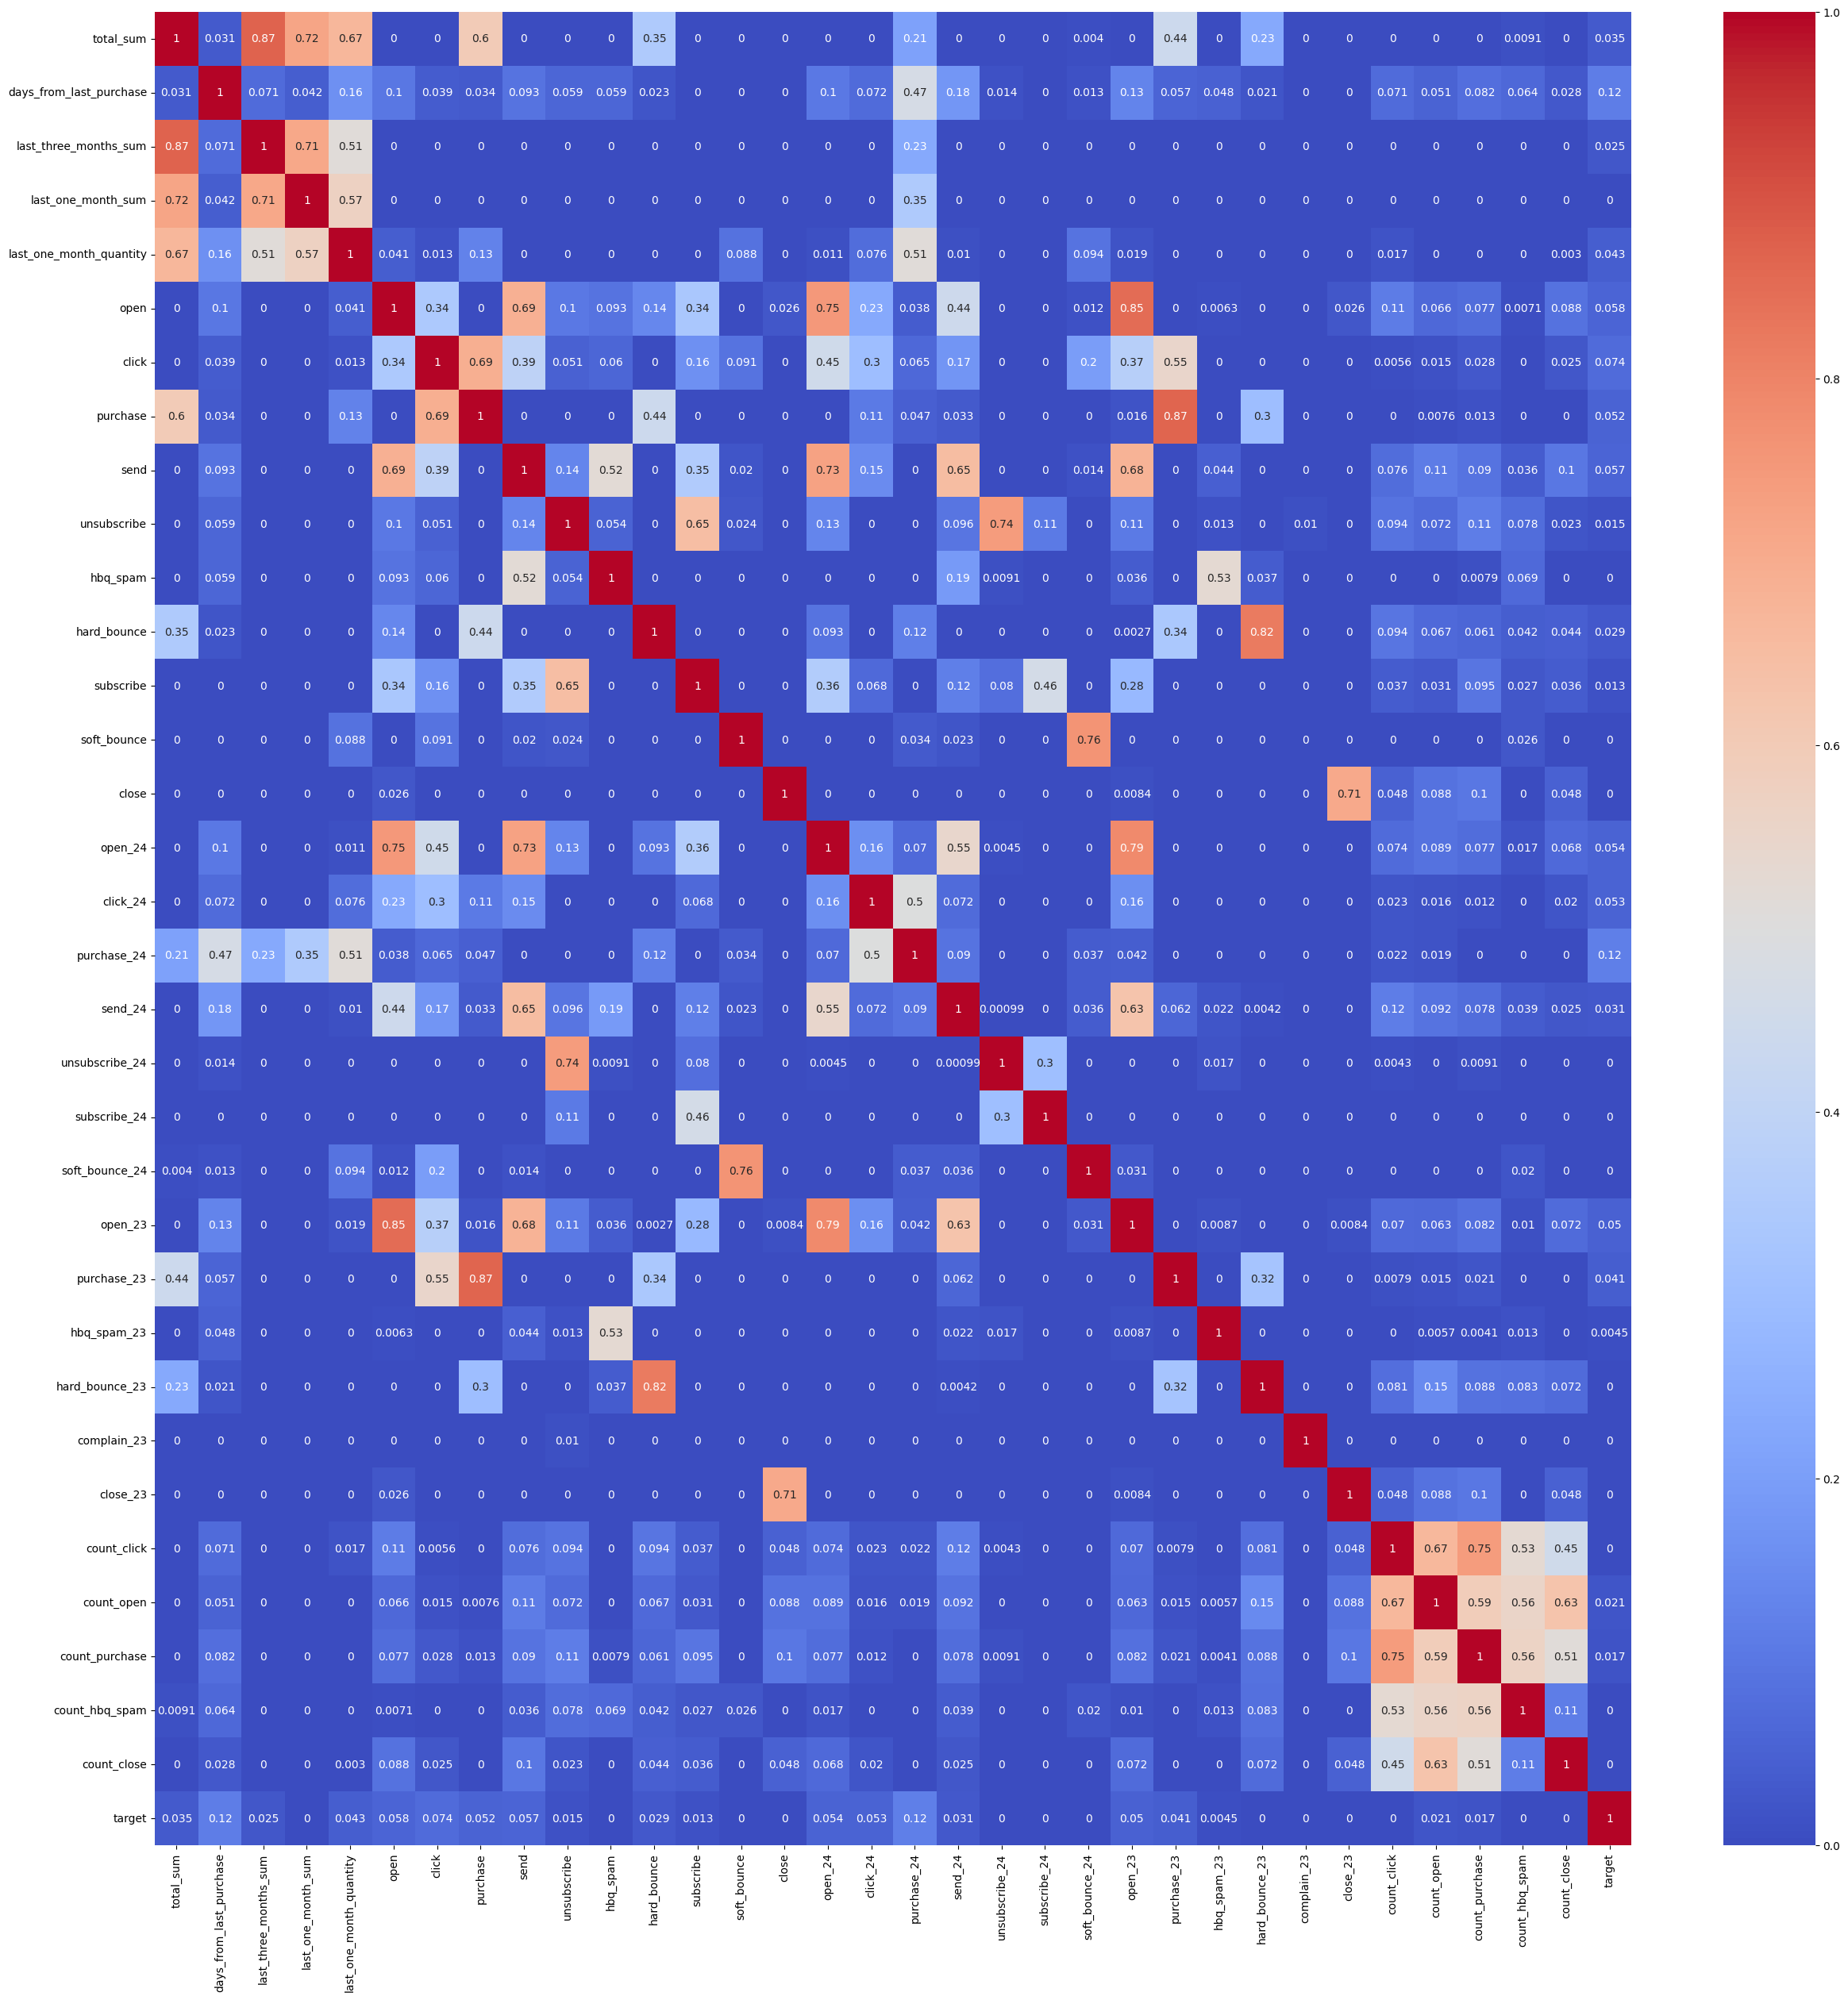

In [37]:

correlation_matrix = phik_matrix(main_dataframe[train_count_columns + ['target']], interval_cols=train_count_columns + ['target'])
fig, ax = plt.subplots(figsize=(30,30)) 
sns.heatmap(correlation_matrix, annot = True, cmap='coolwarm', ax = ax)

<p>
Мы строим матрицу корреляций признаков - удаляем те, которые имеют слишком большую корреляцию. (Часть признаков удалена на этапе формирования таблиц для удобства работы)
</p>

### Построение модели

In [38]:
RANDOM_STATE = 73

In [39]:
cat_pipe = Pipeline(
	[
		('simpleImputer_cat', SimpleImputer(missing_values=np.nan, strategy='most_frequent')),
		('cat', OneHotEncoder(drop='first', handle_unknown='ignore'))
	]
	)

In [40]:
num_pipe = Pipeline(
	[
		('simpleImputer_num_before', SimpleImputer(missing_values=np.nan, strategy='mean')),
		('num', MinMaxScaler()),
		('simpleImputer_num_after', SimpleImputer(missing_values=np.nan, strategy='mean')),
	]
	)

In [41]:
data_preprocessor = ColumnTransformer(
    [
        ('cat', cat_pipe, []),
        ('num', num_pipe, train_count_columns)
    ], 
    remainder='passthrough'
)

In [42]:
pipe_final= Pipeline(
    [
        ('preprocessor', data_preprocessor),
        ('models', DecisionTreeClassifier(random_state = RANDOM_STATE))
    ]
)

In [43]:
param_grid = [
	# словарь для модели DecisionTreeClassifier()
	{
        'models': [GradientBoostingClassifier(random_state=RANDOM_STATE)],
        'models__max_depth':  [3, 4],
        'models__max_features': [3, 4],
		'models__min_samples_split': [500, 700],
		'models__n_estimators': [300],
		'models__min_samples_leaf': [200, 250],
		'models__criterion': ['squared_error', 'friedman_mse'],
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), RobustScaler(), 'passthrough']
    },
	# словарь для модели DecisionTreeClassifier()
	{
        'models': [DecisionTreeClassifier(random_state=RANDOM_STATE)],
        'models__max_depth':  [5, 6, 7, 8],
        'models__max_features': [6, 7, 8, 9],
		'models__min_samples_split': [500],
		'models__min_samples_leaf': [130],
		'models__criterion': ['gini', 'log_loss', 'entropy'],
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), RobustScaler(), 'passthrough']
    },
	# словарь для модели LogisticRegression()
    {
        'models': [LogisticRegression(
            random_state=RANDOM_STATE, 
            solver='liblinear', 
            penalty='l2'
        )],
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), RobustScaler(), 'passthrough']
    },
	# словарь для модели KNeighborsClassifier() 
    {
        'models': [KNeighborsClassifier()],
        'models__n_neighbors': [50, 100],
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), RobustScaler(), 'passthrough']
    }

]

In [44]:
X = main_dataframe.drop([target_column], axis=1)
y = main_dataframe[target_column]

X_train, X_test, y_train, y_test = train_test_split(
	X,
	y,
	test_size = 0.25,
	random_state=RANDOM_STATE,
	stratify=y
)

In [45]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 37386 entries, 16909 to 27632
Data columns (total 36 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   client_id                37386 non-null  int64  
 1   total_sum                37386 non-null  float64
 2   days_from_last_purchase  37386 non-null  int64  
 3   last_three_months_sum    37386 non-null  float64
 4   last_one_month_sum       37386 non-null  float64
 5   last_one_month_quantity  37386 non-null  float64
 6   open                     37386 non-null  float64
 7   click                    37386 non-null  float64
 8   purchase                 37386 non-null  float64
 9   send                     37386 non-null  float64
 10  unsubscribe              37386 non-null  float64
 11  hbq_spam                 37386 non-null  float64
 12  hard_bounce              37386 non-null  float64
 13  subscribe                37386 non-null  float64
 14  soft_bounce            

In [46]:
grid_search = GridSearchCV(
    pipe_final, 
    param_grid, 
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

In [47]:
grid_search.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(remainder='passthrough',
                                                          transformers=[('cat',
                                                                         Pipeline(steps=[('simpleImputer_cat',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('cat',
                                                                                          OneHotEncoder(drop='first',
                                                                                                        handle_unknown='ignore'))]),
                                                                         []),
                                                                        ('num',
                                                                         Pipeline(steps=[('simpleImputer_num_before',
                                                                                          SimpleImputer()),
                                                                                         ('num',
                                                                                          MinMaxSc...
                                                MinMaxScaler(), RobustScaler(),
                                                'passthrough']},
                         {'models': [LogisticRegression(random_state=73,
                                                        solver='liblinear')],
                          'preprocessor__num': [StandardScaler(),
                                                MinMaxScaler(), RobustScaler(),
                                                'passthrough']},
                         {'models': [KNeighborsClassifier()],
                          'models__n_neighbors': [50, 100],
                          'preprocessor__num': [StandardScaler(),
                                                MinMaxScaler(), RobustScaler(),
                                                'passthrough']}],
             scoring='roc_auc')

In [48]:
print('Лучшая модель и её параметры:\n\n', grid_search.best_estimator_)
print ('Метрика лучшей модели во время кросс валидации:', grid_search.best_score_)

Лучшая модель и её параметры:

 Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  Pipeline(steps=[('simpleImputer_cat',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('cat',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore'))]),
                                                  []),
                                                 ('num', StandardScaler(),
                                                  ['total_sum',
                                                   'days_from_last_purchase',
                                                   'last_three_months_

In [49]:
print(grid_search.best_estimator_.get_params())

{'memory': None, 'steps': [('preprocessor', ColumnTransformer(remainder='passthrough',
                  transformers=[('cat',
                                 Pipeline(steps=[('simpleImputer_cat',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'))]),
                                 []),
                                ('num', StandardScaler(),
                                 ['total_sum', 'days_from_last_purchase',
                                  'last_three_months_sum', 'last_one_month_sum',
                                  'last_one_month_quantity', 'open', 'click',
                                  'purchase', 'send', 'unsubscribe', 'hbq_spam',
                                  'hard_bounce', 'subscribe', 'soft_boun

In [50]:
prediction_proba = grid_search.predict_proba(X_test)[:, 1]

In [51]:
print('Метрика roc_auc_score на тестовой выборке = ', roc_auc_score(y_test, prediction_proba))

Метрика roc_auc_score на тестовой выборке =  0.7449146417955221


### Вывод

<p>
Мы построили признаковое представление пользователя из нескольких таблиц с информацией о покупках и рассылках пользователям. В основном использовалась информация о стоимости, количестве и дате покупок, а также характеристики рассылок, с которыми связан пользователь. Вполне возможно, что можно улучшить качество предсказаний учтя категории приобретенных товаров, но они хранятся в неудобном формате и сделать это представляется слишком громоздкой задачей.
</p>

<p>
Затем мы построили пайплайн для создания модели, испробовали несколько моделей, в том числе классификатор knn, логистическую регрессию и решающее дерево, самой эффективной моделью оказался классификатор градиентного бустинга над решающими деревьями. Его показатель roc-auc на этапе кросс валидации равен 0.75. На тестовой выборке показатель roc-auc модели около 0.74.
</p>